In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
R = 6378 # radius earth [km]
M_planet = 5.98e24 # mass earth [kg]
h = 8.5 # scaleheight earth [km]
M_atm = 5.15e18 # earth atmosphere mass [kg]
M0 = M_atm
rho_0 = 1.293e9 # density at earth surface [kg/km^3]
rho = 2e12 # density of planetesimal [kg/km^3]


In [3]:
r_min = r_min = (3*rho_0/rho)**(1/3)*h # minimum impact size [km] ~ 1 km

r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2) # cap size [km] ~ 25 km

r_gi = (2 * h * (R**2))**(1/3) # where giant impacts dominate [km]


r = np.geomspace((r_min + 0.00001),1000,1000) # set up x-axis scale (log)
# print(r)


In [4]:
# N = N0*(r/r_0)**(-q+1)
# q_C = [(2.8, 2.8), (2.5, 1.9), (2.0, 1.3), (1.5, 1.1)]

# print(q_C[0][0])

In [5]:
N_0 = 1 # impactor flux
r_0 = 1 # impactor radius 

def dM_atmos(q, C):
    """Atmospheric mass loss through impactors"""
    if q >= 3:
        r_min = (3*rho_0/rho)**(1/3)*h
        m_min = 4*np.pi*rho_0*h**3
        
        dM = - np.pi * R**2 * ((N_0*m_min)/(q-3)) * (r_min/r_0)**(-q+1)
        
    elif 3 > q > 1:
        r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2)
        M_cap = 2*np.pi*rho_0*(h**2)*R
        
        dM = - np.pi * R**2 * C * N_0 * M_cap * (r_cap/r_0)**(-q+1)
        
    return dM


In [6]:
q = [4.5, 4.0, 3.5, 3.1, 2.8, 2.5, 2.0, 1.5] # 4.5
C = [None, None, None, None, 2.8, 1.9, 1.3, 1.1] # None

# q = [2.8, 2.5, 2.0, 1.5] # 4.5
# C = [2.8, 1.9, 1.3, 1.1] # None

dM_list = []

for i in range(len(q)):
    dM = dM_atmos(q[i], C[i])
    print(dM)
    dM_list.append(dM)
    
dM = np.array(dM_list)


-6.932477811747384e+20
-1.0706253134874758e+21
-2.204576955034855e+21
-1.12829191413836e+22
-4.1252736312854446e+21
-7.338981943381218e+21
-2.503060720962524e+22
-1.05576323060831e+23


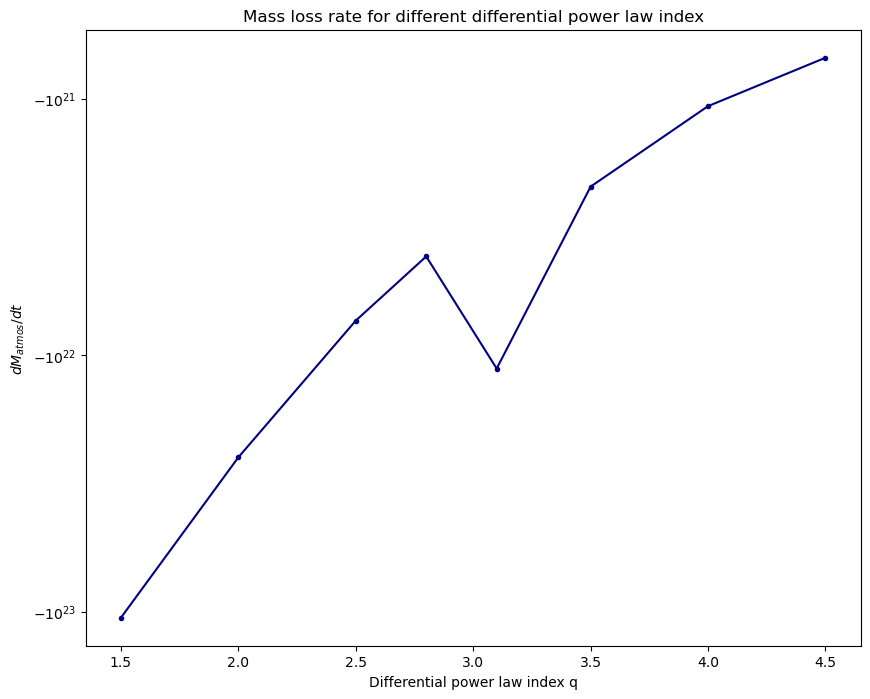

In [11]:
plt.figure(figsize=(10,8))
plt.plot(q, dM, color='navy', marker='.')
plt.xlabel('Differential power law index q')
plt.ylabel(r'$dM_{atmos}/dt$')
plt.title(r'Mass loss rate for different differential power law index')
plt.yscale('symlog')
# plt.legend()
# plt.savefig('Mtotal_vs_impactor_rad')
plt.show()


In [8]:
def M_atmos(q, C, t):
    """Mass atmosphere over time"""
    m0 = 4*np.pi * rho * r_0**3 / 3
    
    if q>3:
        t_star = ((3*(q-3))/(np.pi*(q-1)*(h**2)*N_0)) * ((h/R)**2 * M0/m0 )**((q-1)/3)
        
    elif q<3:
        t_star = (6 / (np.pi*(q-1)*C*R*h*N_0)) * (np.sqrt(np.pi * h / (8*R))* M0/m0)**((q-1)/3)
        
    M_atmos = M0*(1-(t/t_star))**(3/(q-1))
    
    return M_atmos
    

C:\Users\rensk\AppData\Local\Temp\ipykernel_35244\2924355404.py:11: RuntimeWarning: invalid value encountered in scalar power
  M_atmos = M0*(1-(t/t_star))**(3/(q-1))


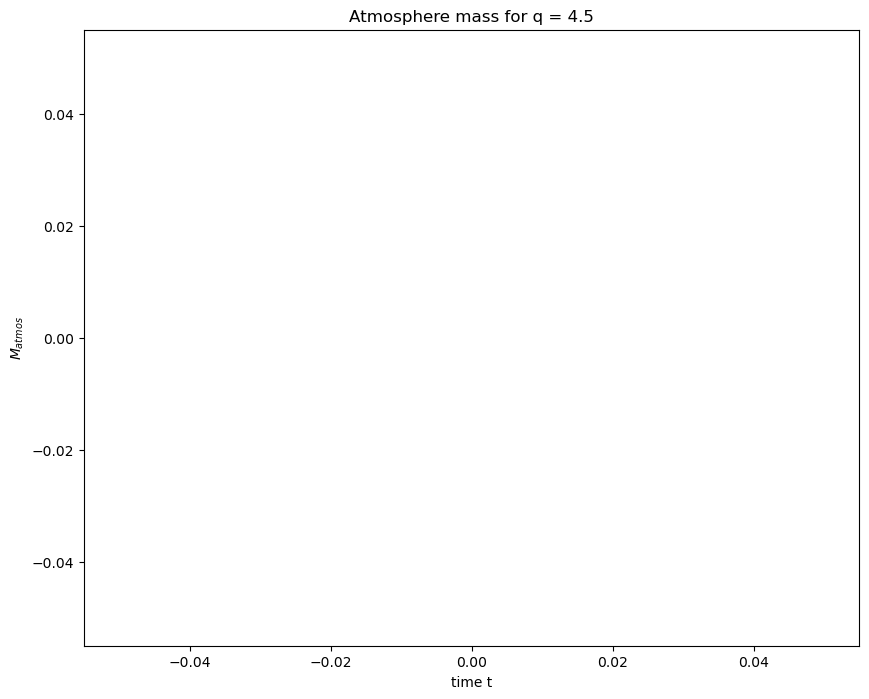

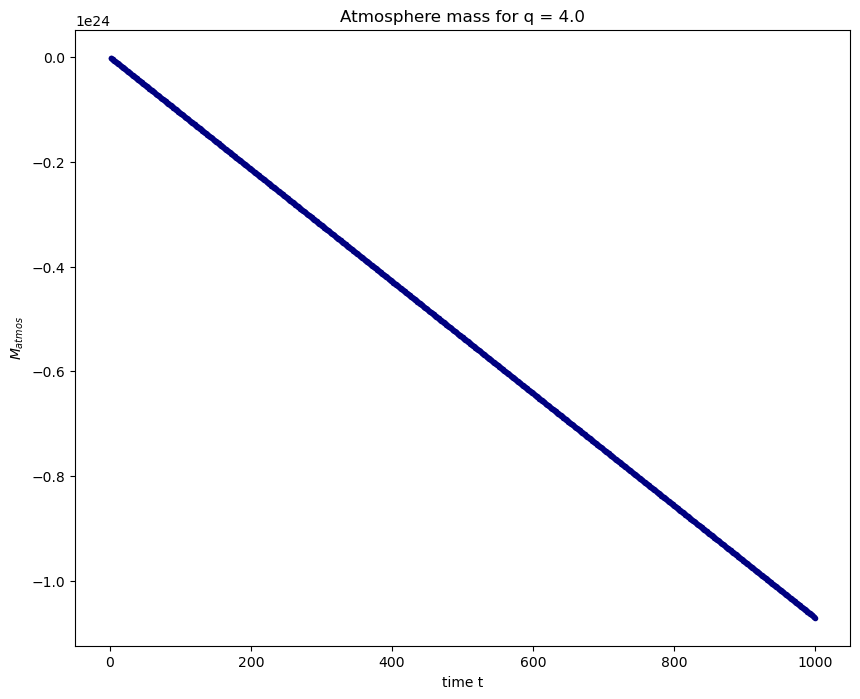

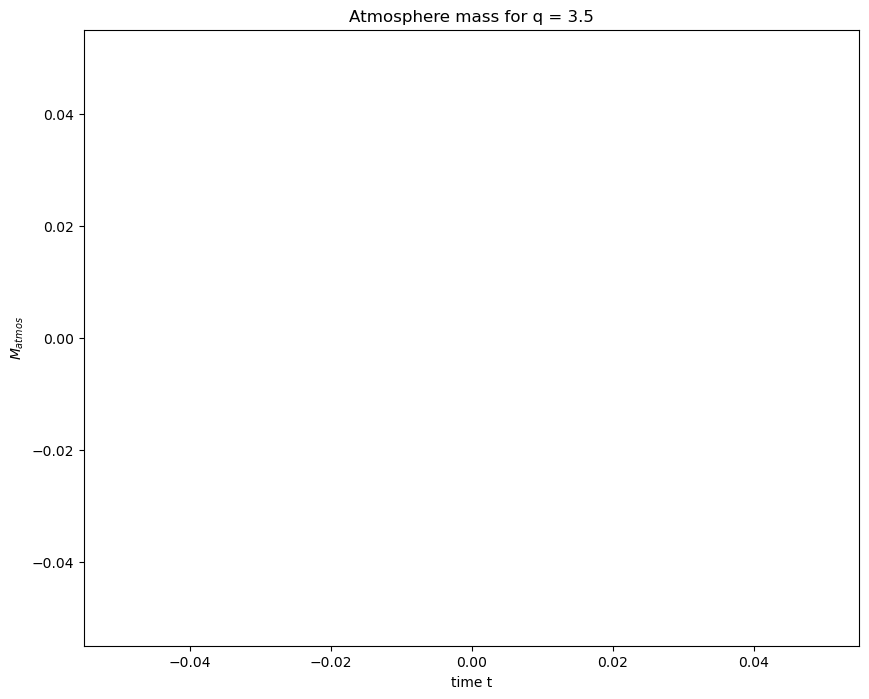

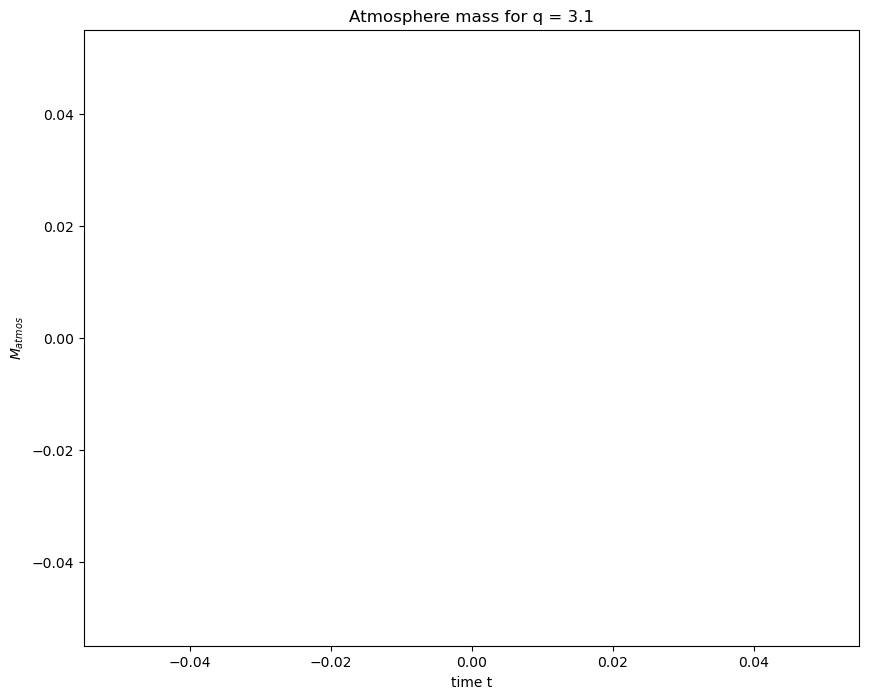

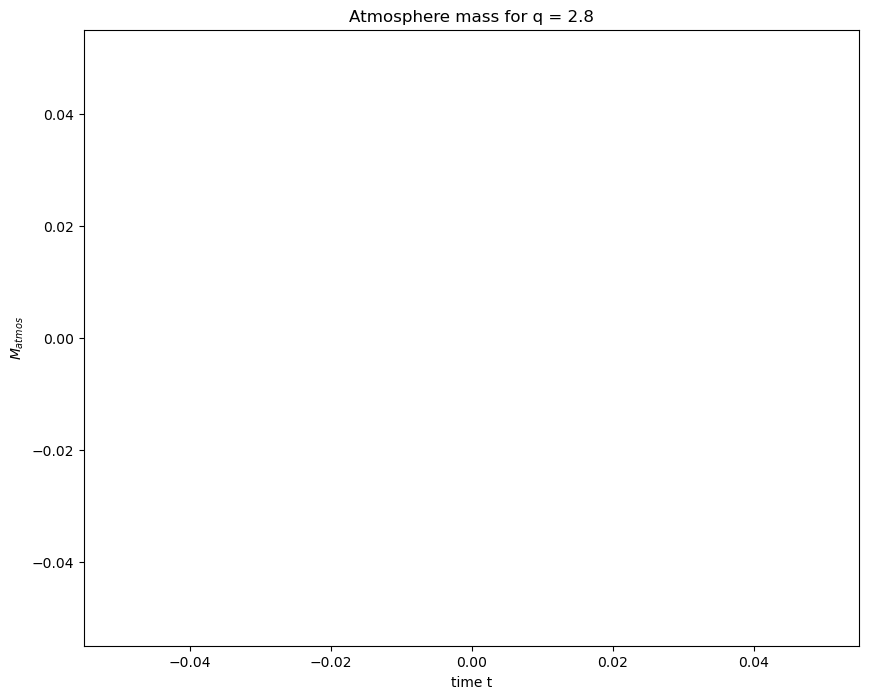

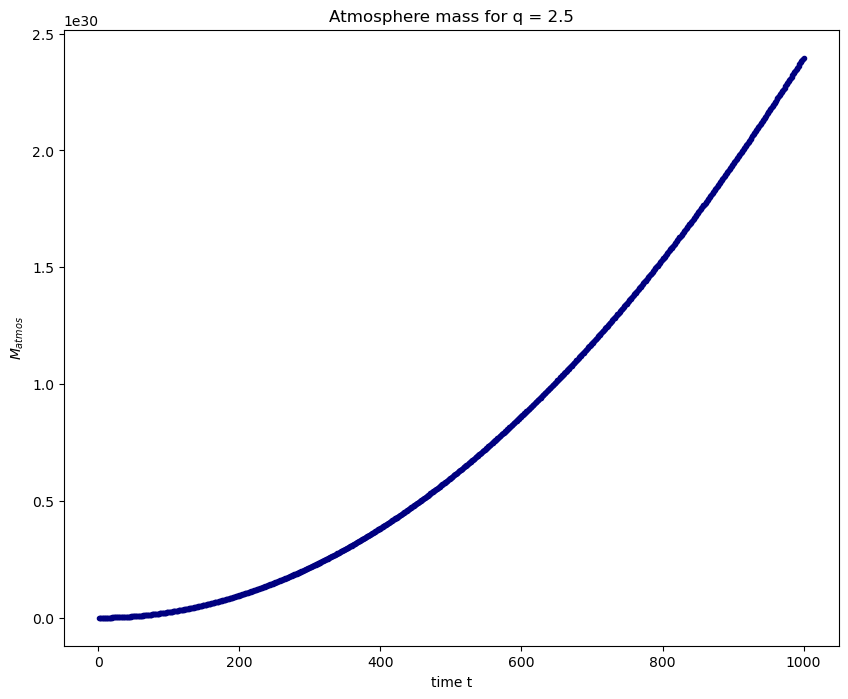

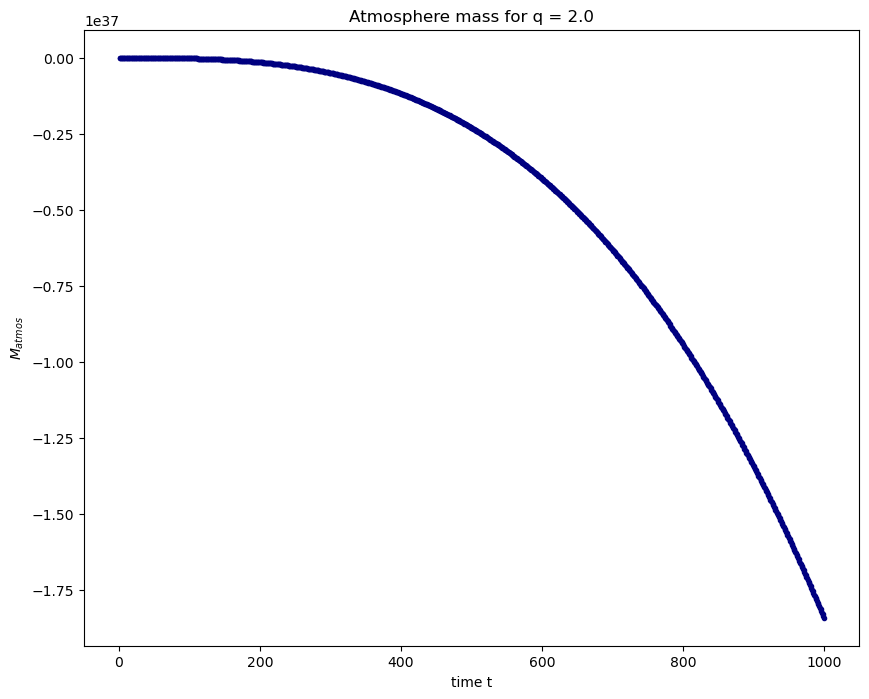

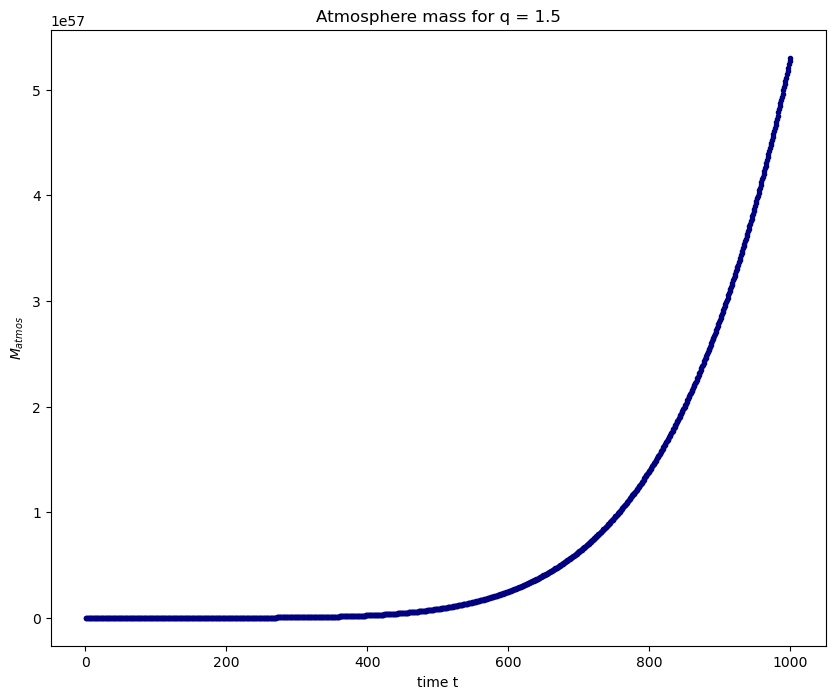

In [9]:
t = np.linspace(1, 1000, 1000)

for i in range(len(q)):
    M_atm = [M_atmos(q[i], C[i], _) for _ in t]
    M_atm = np.array(M_atm)
    
    plt.figure(figsize=(10,8))
    plt.plot(t, M_atm, color='navy', marker='.')
    plt.xlabel('time t')
    plt.ylabel(r'$M_{atmos}$')
    plt.title(f'Atmosphere mass for q = {q[i]}')
    # plt.legend()
    # plt.savefig('Mtotal_vs_impactor_rad')
    plt.show()

In [10]:
M_pl
q
r_min
r_max


NameError: name 'M_pl' is not defined

In [ ]:
def Mt_Mimp_new(M_pl, q, r_min, r_max):
    """"""
    